EXTRATREES REGRESSOR - CHARGEMENT DES DONNEES
Chargement termine.
Temps de chargement : 18.65 secondes
Dimensions X_train : (3712444, 13)
Dimensions X_test  : (928111, 13)
Dimensions y_train : (3712444,)
Dimensions y_test  : (928111,)

Apercu des variables explicatives :


,surface_reelle_bati,nombre_pieces_principales,surface_terrain,annee,mois,code_departement,longitude,latitude,is_maison,is_neuf,anciennete_mois,commune_prix_m2,commune_volume
0,142.0,7,256.0,2022,9,18,1.862602,47.141060,1,0,39,692.307692,135
1,56.0,3,0.0,2024,11,17,-1.147863,46.161465,0,0,13,4676.056338,7765
2,70.0,4,415.0,2024,10,56,-3.287295,48.087668,1,0,14,810.826165,136
3,73.0,4,552.0,2021,12,86,0.548029,46.772399,1,0,48,1311.740891,104
4,75.0,5,80.0,2022,7,34,3.461843,43.381660,1,0,41,2226.785714,460



Valeurs manquantes dans X_train :


surface_reelle_bati          0
nombre_pieces_principales    0
surface_terrain              0
annee                        0
mois                         0
code_departement             0
longitude                    0
latitude                     0
is_maison                    0
is_neuf                      0
anciennete_mois              0
commune_prix_m2              0
commune_volume               0
dtype: int64


Modele ExtraTrees cree :
ExtraTreesRegressor(max_depth=20, min_samples_leaf=10, n_jobs=-1,
                    random_state=42, verbose=1)

Debut de l'entrainement ExtraTrees...


...

Entrainement termine en 24.37 minutes.

Predictions sur le jeu de test...


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    8.6s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:   19.7s finished


Predictions terminees en 20.29 secondes.

RESULTATS DU MODELE : EXTRATREES REGRESSOR
R2 Score                  : 0.7287
MAE - Erreur moyenne      : 62,368.85 euros
RMSE - Erreur quadratique : 129,650.06 euros
MAPE - Erreur en %        : 34.94 %
Temps d'entrainement      : 24.37 minutes
Temps de prediction       : 20.29 secondes

Top 10 des variables les plus importantes :


,Variable,Importance
11,commune_prix_m2,0.466495
0,surface_reelle_bati,0.361795
1,nombre_pieces_principales,0.066185
8,is_maison,0.038823
2,surface_terrain,0.014891
12,commune_volume,0.012426
6,longitude,0.010206
7,latitude,0.008801
10,anciennete_mois,0.005305
3,annee,0.004679


C:\Users\a\AppData\Local\Temp\ipykernel_15944\4225670761.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


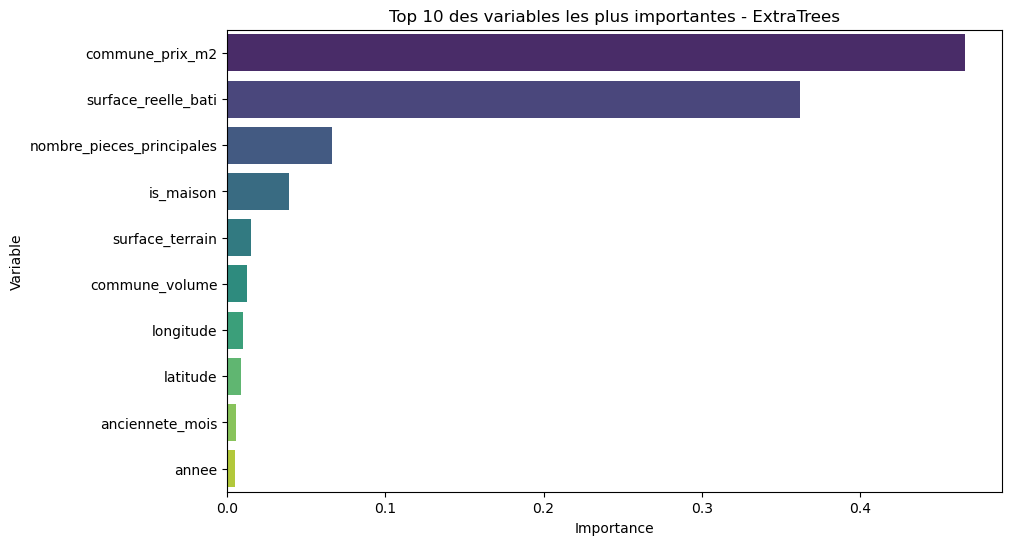

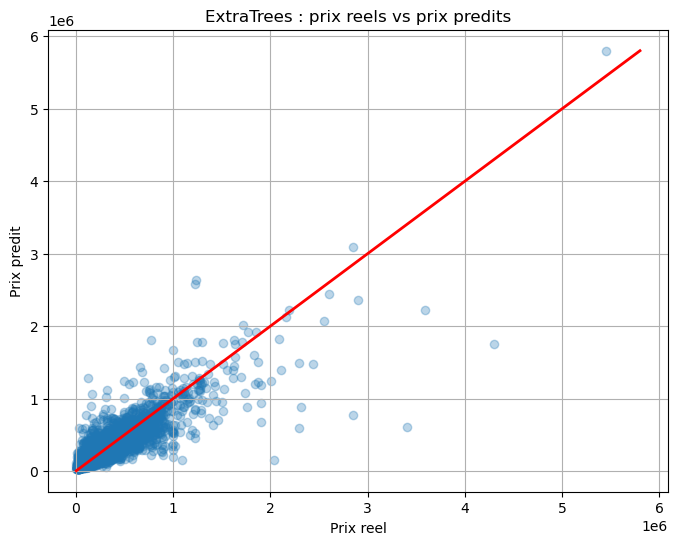


INTERPRETATION
- ExtraTrees est un modele non lineaire base sur un ensemble d'arbres.
- Il est proche du Random Forest mais ajoute plus d'aleatoire dans la creation des arbres.
- Il peut capturer des interactions complexes entre surface, localisation, type de bien et dynamique communale.
- L'importance des variables permet d'identifier les facteurs les plus determinants dans la prediction du prix immobilier.


In [1]:
# ============================================================
# EXTRATREES REGRESSOR - MODELISATION DU PRIX IMMOBILIER
# ============================================================

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

print("=" * 60)
print("EXTRATREES REGRESSOR - CHARGEMENT DES DONNEES")
print("=" * 60)

start_time = time.time()

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

load_time = time.time() - start_time

print("Chargement termine.")
print(f"Temps de chargement : {load_time:.2f} secondes")
print(f"Dimensions X_train : {X_train.shape}")
print(f"Dimensions X_test  : {X_test.shape}")
print(f"Dimensions y_train : {y_train.shape}")
print(f"Dimensions y_test  : {y_test.shape}")

print("\nApercu des variables explicatives :")
display(X_train.head())

print("\nValeurs manquantes dans X_train :")
display(X_train.isna().sum())

# ------------------------------------------------------------
# Creation du modele
# ------------------------------------------------------------
# ExtraTrees est un modele d'ensemble base sur des arbres.
# Il capture des relations non lineaires entre les variables.

extra_model = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("\nModele ExtraTrees cree :")
print(extra_model)

# ------------------------------------------------------------
# Entrainement
# ------------------------------------------------------------

print("\nDebut de l'entrainement ExtraTrees...")
start_train = time.time()

extra_model.fit(X_train, y_train)

train_time = time.time() - start_train
print(f"Entrainement termine en {train_time/60:.2f} minutes.")

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

print("\nPredictions sur le jeu de test...")
start_pred = time.time()

y_pred_extra = extra_model.predict(X_test)

pred_time = time.time() - start_pred
print(f"Predictions terminees en {pred_time:.2f} secondes.")

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------

mae_extra = mean_absolute_error(y_test, y_pred_extra)
rmse_extra = np.sqrt(mean_squared_error(y_test, y_pred_extra))
r2_extra = r2_score(y_test, y_pred_extra)

mask = y_test != 0
mape_extra = np.mean(np.abs((y_test[mask] - y_pred_extra[mask]) / y_test[mask])) * 100

print("\n" + "=" * 60)
print("RESULTATS DU MODELE : EXTRATREES REGRESSOR")
print("=" * 60)
print(f"R2 Score                  : {r2_extra:.4f}")
print(f"MAE - Erreur moyenne      : {mae_extra:,.2f} euros")
print(f"RMSE - Erreur quadratique : {rmse_extra:,.2f} euros")
print(f"MAPE - Erreur en %        : {mape_extra:.2f} %")
print(f"Temps d'entrainement      : {train_time/60:.2f} minutes")
print(f"Temps de prediction       : {pred_time:.2f} secondes")
print("=" * 60)

# ------------------------------------------------------------
# Importance des variables
# ------------------------------------------------------------

feature_importance_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Importance": extra_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 des variables les plus importantes :")
display(feature_importance_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_df.head(10),
    x="Importance",
    y="Variable",
    palette="viridis"
)
plt.title("Top 10 des variables les plus importantes - ExtraTrees")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()

# ------------------------------------------------------------
# Graphique prix reels vs prix predits
# ------------------------------------------------------------

sample_size = 10000
y_test_sample = y_test[:sample_size]
y_pred_sample = y_pred_extra[:sample_size]

plt.figure(figsize=(8, 6))
plt.scatter(y_test_sample, y_pred_sample, alpha=0.3)

min_val = min(y_test_sample.min(), y_pred_sample.min())
max_val = max(y_test_sample.max(), y_pred_sample.max())

plt.plot([min_val, max_val], [min_val, max_val], color="red", linewidth=2)

plt.title("ExtraTrees : prix reels vs prix predits")
plt.xlabel("Prix reel")
plt.ylabel("Prix predit")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Interpretation synthetique
# ------------------------------------------------------------

print("\nINTERPRETATION")
print("- ExtraTrees est un modele non lineaire base sur un ensemble d'arbres.")
print("- Il est proche du Random Forest mais ajoute plus d'aleatoire dans la creation des arbres.")
print("- Il peut capturer des interactions complexes entre surface, localisation, type de bien et dynamique communale.")
print("- L'importance des variables permet d'identifier les facteurs les plus determinants dans la prediction du prix immobilier.")
